# Fase 2 - Realtime Polygon Analytics

Este notebook arranca la fase 2 del prototipo. El objetivo ya no es demostrar que el stream entra, sino transformar la captura raw en datasets analíticos reutilizables, persistidos y medibles.

## Celda 0. Configuración compartida de fase 2

Esta celda centraliza la etiqueta de la captura que se va a procesar y las rutas base del proyecto. Toda la fase 2 trabaja sobre artefactos generados previamente por la fase 1.

Motivo: la fase 2 no consume el WebSocket directamente; consume una captura ya realizada. Por eso conviene fijar desde el principio qué run se está normalizando y cargando.

Resultado esperado: variables Python compartidas para todas las celdas posteriores.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\\TSIS_Data\\v1\\WebSocket_SmallCaps")
CELL_CODE_DIR = PROJECT_ROOT / "notebooks" / "cell_code"
# label = "prototype_run"
label = "prototype_run_phase3_A"

print({"label": label, "project_root": str(PROJECT_ROOT)})

{'label': 'prototype_run_phase3_A', 'project_root': 'C:\\TSIS_Data\\v1\\WebSocket_SmallCaps'}


## Celda 1. Normalización por feed

Este script lee `events.jsonl` y separa la captura raw por tipo de feed, generando tablas normalizadas para `trades`, `quotes`, `minute_aggs`, `second_aggs` y `status`.

Motivo: en fase 1 preservamos el raw completo. En fase 2 necesitamos datasets con columnas estables y semántica específica por feed para poder analizarlos y consultarlos.

Resultado esperado: archivos parquet normalizados y un `manifest.json` con filas por dataset.

In [2]:
import subprocess, sys

script = CELL_CODE_DIR / "10_normalize_by_feed.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label
], capture_output=True, text=True)

print("RETURN CODE:", result.returncode)
print("\nSTDOUT:\n", result.stdout)
print("\nSTDERR:\n", result.stderr)

RETURN CODE: 0

STDOUT:
 {
  "trades": {
    "rows": 1761,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\trades.parquet",
    "written": true
  },
  "quotes": {
    "rows": 1230,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\quotes.parquet",
    "written": true
  },
  "minute_aggs": {
    "rows": 12,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\minute_aggs.parquet",
    "written": true
  },
  "second_aggs": {
    "rows": 182,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\second_aggs.parquet",
    "written": true
  },
  "status": {
    "rows": 17,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\status.parquet",
    "written": true
  }
}

Manifest: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\

In [3]:
import subprocess, sys

script = CELL_CODE_DIR / "10_normalize_by_feed.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label
], capture_output=True, text=True, check=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)

{
  "trades": {
    "rows": 1761,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\trades.parquet",
    "written": true
  },
  "quotes": {
    "rows": 1230,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\quotes.parquet",
    "written": true
  },
  "minute_aggs": {
    "rows": 12,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\minute_aggs.parquet",
    "written": true
  },
  "second_aggs": {
    "rows": 182,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\second_aggs.parquet",
    "written": true
  },
  "status": {
    "rows": 17,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\status.parquet",
    "written": true
  }
}

Manifest: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_

## Celda 2. Escritura particionada a Parquet

Este script toma los datasets normalizados y los reescribe en estructura particionada por fecha de evento y ticker. Esto acerca el prototipo a un layout utilizable para consultas incrementales y para almacenamiento más serio.

Motivo: un único parquet por dataset sirve para pruebas pequeñas, pero escala peor. La partición por `event_date` y `sym` permite trabajar después con filtros más eficientes.

Resultado esperado: carpetas particionadas por dataset y un `partition_report.json`.

In [4]:
import subprocess, sys

script = CELL_CODE_DIR / "11_write_partitioned_parquet.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label
], capture_output=True, text=True, check=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)

{
  "trades": {
    "written": true,
    "rows": 1761,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\partitioned\\trades",
    "partitions": 4
  },
  "quotes": {
    "written": true,
    "rows": 1230,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\partitioned\\quotes",
    "partitions": 4
  },
  "minute_aggs": {
    "written": true,
    "rows": 12,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\partitioned\\minute_aggs",
    "partitions": 4
  },
  "second_aggs": {
    "written": true,
    "rows": 182,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\partitioned\\second_aggs",
    "partitions": 4
  }
}

Partition report: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_A\partitioned\partition_report.json



## Celda 3. Construcción de la base analítica DuckDB

Este script carga los parquets normalizados en una base DuckDB local. La idea es disponer de una capa de consulta rápida para explorar la captura sin reparsear JSON ni depender de pandas para todo.

Motivo: DuckDB da una base ligera, muy útil para prototipos analíticos, validación de esquemas y futuras consultas desde backend o notebooks adicionales.

Resultado esperado: un archivo `analytics.duckdb` y un `duckdb_report.json` con las tablas cargadas.

In [5]:
import subprocess, sys

script = CELL_CODE_DIR / "12_build_duckdb.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label
], capture_output=True, text=True, check=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)

{
  "trades": {
    "loaded": true,
    "rows": 1761,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\trades.parquet"
  },
  "quotes": {
    "loaded": true,
    "rows": 1230,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\quotes.parquet"
  },
  "minute_aggs": {
    "loaded": true,
    "rows": 12,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\minute_aggs.parquet"
  },
  "second_aggs": {
    "loaded": true,
    "rows": 182,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\second_aggs.parquet"
  },
  "status": {
    "loaded": true,
    "rows": 17,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\status.parquet"
  }
}

DuckDB: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_

## Celda 4. Métricas de captura y calidad inicial

Este script calcula métricas básicas del run: tamaño del raw, eventos por mensaje, distribución por dataset, símbolos presentes y latencia aproximada de captura para `trades`.

Motivo: la fase 2 no está completa si no sabemos cuánto cuesta capturar y qué calidad tiene lo ingerido. Estas métricas sirven para detectar cuellos de botella y validar si el pipeline soportará más volumen.

Resultado esperado: un `metrics.json` con medidas operativas y primeras estadísticas de latencia.

In [6]:
import subprocess, sys

script = CELL_CODE_DIR / "13_capture_metrics.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label
], capture_output=True, text=True, check=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)

{
  "capture_duration_sec": 180,
  "total_messages": 2006,
  "total_events": 3202,
  "events_per_message": 1.5962,
  "raw_size_bytes": 600196,
  "datasets": {
    "trades": {
      "rows": 1761,
      "exists": true,
      "columns": [
        "captured_at_utc",
        "sym",
        "event_time",
        "sequence",
        "trade_id",
        "exchange",
        "price",
        "size",
        "tape",
        "conditions",
        "raw_event"
      ],
      "symbols": {
        "LNAI": 1317,
        "KNDI": 229,
        "OCG": 112,
        "LIDR": 103
      },
      "timing_observation_ms": {
        "definition": "captured_at_utc minus event_time",
        "note": "Esto no debe interpretarse como latencia operativa fiable sin modelar mejor la semantica del timestamp del feed y el reloj local.",
        "min": -219.93,
        "max": -8.561,
        "median": -214.095,
        "mean": -204.383
      }
    },
    "quotes": {
      "rows": 1230,
      "exists": true,
      "columns":

## Nota historica de validacion

Esta celda conserva un resumen historico de una ejecucion anterior de fase 2 sobre `prototype_run`. Sirve como referencia narrativa, pero no debe interpretarse como el estado actual del notebook cuando cambie el `label`.

Motivo: los valores listados aqui estan hardcodeados y no se actualizan automaticamente con cada nueva captura. La fuente de verdad actual para cada run son las celdas ejecutables y los artefactos generados (`manifest.json`, `partition_report.json`, `duckdb_report.json`, `metrics.json`).

Resumen historico de esa ejecucion:

- Fase 1: cerrada funcionalmente.
- Fase 2: arrancada y validada sobre `prototype_run`.
- DuckDB: tablas `trades`, `minute_aggs`, `status`.
- Los feeds `quotes` y `second_aggs` quedaron vacios porque en fase 1 no se suscribieron `Q` ni `A`.
- La metrica temporal inicial necesitaba refinarse y por eso no debe usarse como latencia definitiva.


## Celda 5. Revisi?n visual del contenido normalizado

Estas celdas ya no validan transporte, sino estructura anal?tica. Aqu? se inspeccionan directamente los parquets normalizados generados en fase 2 para comprobar qu? tablas existen, cu?ntas filas tienen y c?mo se ven sus primeras observaciones.

Motivo: antes de apoyarnos en SQL o en futuras capas de serving, conviene validar visualmente que la normalizaci?n por feed ha producido datasets coherentes y legibles.

Resultado esperado: manifest de datasets, lista de columnas por tabla y muestras visibles de `trades`, `minute_aggs` y cualquier otro feed que exista para el run seleccionado.

In [7]:
import json
import pandas as pd

normalized_dir = PROJECT_ROOT / "data" / "curated_ws" / label / "normalized"
manifest_path = normalized_dir / "manifest.json"

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
print("MANIFEST")
print(json.dumps(manifest, indent=2, ensure_ascii=False))

for dataset in ["trades", "quotes", "minute_aggs", "second_aggs", "status"]:
    parquet_path = normalized_dir / f"{dataset}.parquet"
    print(f"\n===== {dataset.upper()} =====")
    print(f"path: {parquet_path}")
    if not parquet_path.exists():
        print("No existe parquet para este dataset")
        continue
    df = pd.read_parquet(parquet_path)
    print(f"rows={len(df)} cols={len(df.columns)}")
    print(f"columns={list(df.columns)}")
    if not df.empty:
        display(df.head(10))


MANIFEST
{
  "trades": {
    "rows": 1761,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\trades.parquet",
    "written": true
  },
  "quotes": {
    "rows": 1230,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\quotes.parquet",
    "written": true
  },
  "minute_aggs": {
    "rows": 12,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\minute_aggs.parquet",
    "written": true
  },
  "second_aggs": {
    "rows": 182,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\second_aggs.parquet",
    "written": true
  },
  "status": {
    "rows": 17,
    "path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A\\normalized\\status.parquet",
    "written": true
  }
}

===== TRADES =====
path: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\c

,captured_at_utc,sym,event_time,sequence,trade_id,exchange,price,size,tape,conditions,raw_event
0,2026-03-17T11:52:46.607839+00:00,OCG,1773748366821,217171,2183,12,0.7769,25,3,"[14, 12, 37, 41]","{""ev"":""T"",""sym"":""OCG"",""i"":""2183"",""x"":12,""p"":0...."
1,2026-03-17T11:52:47.319579+00:00,OCG,1773748367532,217173,7918,8,0.7780,1,3,"[12, 37]","{""ev"":""T"",""sym"":""OCG"",""i"":""7918"",""x"":8,""p"":0.7..."
2,2026-03-17T11:52:48.459269+00:00,OCG,1773748368670,217175,7919,8,0.7780,375,3,[12],"{""ev"":""T"",""sym"":""OCG"",""i"":""7919"",""x"":8,""p"":0.7..."
3,2026-03-17T11:52:48.459328+00:00,LIDR,1773748368672,153801,16784,8,2.1600,39,3,"[12, 37]","{""ev"":""T"",""sym"":""LIDR"",""i"":""16784"",""x"":8,""p"":2..."
4,2026-03-17T11:52:50.913832+00:00,LNAI,1773748371130,217253,13192,21,0.4165,2,3,"[14, 12, 37, 41]","{""ev"":""T"",""sym"":""LNAI"",""i"":""13192"",""x"":21,""p"":..."
5,2026-03-17T11:52:54.011473+00:00,LIDR,1773748374225,153836,151,2,2.1500,53,3,"[12, 37]","{""ev"":""T"",""sym"":""LIDR"",""i"":""151"",""x"":2,""p"":2.1..."
6,2026-03-17T11:52:54.011659+00:00,LIDR,1773748374226,153837,1663,20,2.1500,400,3,[12],"{""ev"":""T"",""sym"":""LIDR"",""i"":""1663"",""x"":20,""p"":2..."
7,2026-03-17T11:52:54.205817+00:00,LNAI,1773748374418,217273,13193,21,0.4165,1,3,"[14, 12, 37, 41]","{""ev"":""T"",""sym"":""LNAI"",""i"":""13193"",""x"":21,""p"":..."
8,2026-03-17T11:52:57.217120+00:00,LNAI,1773748377431,217279,13194,21,0.4165,142,3,[12],"{""ev"":""T"",""sym"":""LNAI"",""i"":""13194"",""x"":21,""p"":..."
9,2026-03-17T11:52:57.796669+00:00,LNAI,1773748377999,217284,31292,8,0.4169,10,3,"[12, 37]","{""ev"":""T"",""sym"":""LNAI"",""i"":""31292"",""x"":8,""p"":0..."



===== QUOTES =====
path: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_A\normalized\quotes.parquet
rows=1230 cols=14
columns=['captured_at_utc', 'sym', 'event_time', 'sequence', 'bid_exchange', 'bid_price', 'bid_size', 'ask_exchange', 'ask_price', 'ask_size', 'conditions', 'indicators', 'tape', 'raw_event']


,captured_at_utc,sym,event_time,sequence,bid_exchange,bid_price,bid_size,ask_exchange,ask_price,ask_size,conditions,indicators,tape,raw_event
0,2026-03-17T11:52:47.288284+00:00,LNAI,1773748367460,2083981,11,0.4150,100,21,0.4169,6600,null,null,3,"{""ev"":""Q"",""sym"":""LNAI"",""bx"":11,""ax"":21,""bp"":0...."
1,2026-03-17T11:52:47.355719+00:00,OCG,1773748367532,2083992,8,0.7758,400,8,0.7780,1000,null,null,3,"{""ev"":""Q"",""sym"":""OCG"",""bx"":8,""ax"":8,""bp"":0.775..."
2,2026-03-17T11:52:48.482814+00:00,LIDR,1773748368673,2436281,8,2.1500,3600,11,2.1600,2300,null,[604],3,"{""ev"":""Q"",""sym"":""LIDR"",""i"":[604],""bx"":8,""ax"":1..."
3,2026-03-17T11:52:48.482867+00:00,LIDR,1773748368673,2436285,8,2.1500,3600,11,2.1600,2100,null,[604],3,"{""ev"":""Q"",""sym"":""LIDR"",""i"":[604],""bx"":8,""ax"":1..."
4,2026-03-17T11:52:48.482885+00:00,LIDR,1773748368673,2436287,8,2.1500,3600,11,2.1600,1700,null,[604],3,"{""ev"":""Q"",""sym"":""LIDR"",""i"":[604],""bx"":8,""ax"":1..."
5,2026-03-17T11:52:48.487068+00:00,OCG,1773748368670,2084167,8,0.7758,300,8,0.7780,1000,null,null,3,"{""ev"":""Q"",""sym"":""OCG"",""bx"":8,""ax"":8,""bp"":0.775..."
6,2026-03-17T11:52:48.487105+00:00,OCG,1773748368670,2084168,12,0.7758,200,8,0.7780,1000,null,null,3,"{""ev"":""Q"",""sym"":""OCG"",""bx"":12,""ax"":8,""bp"":0.77..."
7,2026-03-17T11:52:48.487120+00:00,OCG,1773748368670,2084169,12,0.7758,200,8,0.7780,600,null,null,3,"{""ev"":""Q"",""sym"":""OCG"",""bx"":12,""ax"":8,""bp"":0.77..."
8,2026-03-17T11:52:48.487132+00:00,OCG,1773748368670,2084170,8,0.7758,200,8,0.7780,600,null,null,3,"{""ev"":""Q"",""sym"":""OCG"",""bx"":8,""ax"":8,""bp"":0.775..."
9,2026-03-17T11:52:48.590195+00:00,LNAI,1773748368787,2084181,11,0.4150,100,21,0.4165,100,null,null,3,"{""ev"":""Q"",""sym"":""LNAI"",""bx"":11,""ax"":21,""bp"":0...."



===== MINUTE_AGGS =====
path: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_A\normalized\minute_aggs.parquet
rows=12 cols=16
columns=['captured_at_utc', 'sym', 'window_start', 'window_end', 'open', 'high', 'low', 'close', 'vwap', 'avg_size', 'volume', 'accumulated_volume', 'official_open', 'tape', 'otc', 'raw_event']


,captured_at_utc,sym,window_start,window_end,open,high,low,close,vwap,avg_size,volume,accumulated_volume,official_open,tape,otc,raw_event
0,2026-03-17T11:53:00.791529+00:00,LIDR,1773748320000,1773748380000,2.1600,2.1600,2.1500,2.1500,2.1586,2.1318,15853,8499000,None,200,None,"{""ev"":""AM"",""sym"":""LIDR"",""v"":15853,""av"":8499000..."
1,2026-03-17T11:53:00.802583+00:00,OCG,1773748320000,1773748380000,0.7800,0.7800,0.7758,0.7780,0.7785,0.9377,4325,5010301,None,180,None,"{""ev"":""AM"",""sym"":""OCG"",""v"":4325,""av"":5010301,""..."
2,2026-03-17T11:53:00.807781+00:00,KNDI,1773748320000,1773748380000,0.8730,0.8800,0.8730,0.8750,0.8745,1.0832,3507,4388791,None,584,None,"{""ev"":""AM"",""sym"":""KNDI"",""v"":3507,""av"":4388791,..."
3,2026-03-17T11:53:00.807812+00:00,LNAI,1773748320000,1773748380000,0.4176,0.4200,0.4155,0.4165,0.4181,0.3925,48621,39520545,None,317,None,"{""ev"":""AM"",""sym"":""LNAI"",""v"":48621,""av"":3952054..."
4,2026-03-17T11:54:00.793000+00:00,LIDR,1773748380000,1773748440000,2.1500,2.1600,2.1500,2.1500,2.1520,2.1318,2875,8501875,None,143,None,"{""ev"":""AM"",""sym"":""LIDR"",""v"":2875,""av"":8501875,..."
5,2026-03-17T11:54:00.793567+00:00,OCG,1773748380000,1773748440000,0.7780,0.7900,0.7769,0.7769,0.7828,0.9374,8625,5018926,None,246,None,"{""ev"":""AM"",""sym"":""OCG"",""v"":8625,""av"":5018926,""..."
6,2026-03-17T11:54:00.803785+00:00,LNAI,1773748380000,1773748440000,0.4165,0.4165,0.4073,0.4087,0.4095,0.3925,83278,39603823,None,338,None,"{""ev"":""AM"",""sym"":""LNAI"",""v"":83278,""av"":3960382..."
7,2026-03-17T11:54:00.803824+00:00,KNDI,1773748380000,1773748440000,0.8750,0.8750,0.8506,0.8506,0.8584,1.0821,21249,4410040,None,152,None,"{""ev"":""AM"",""sym"":""KNDI"",""v"":21249,""av"":4410040..."
8,2026-03-17T11:55:00.788898+00:00,OCG,1773748440000,1773748500000,0.7927,0.8101,0.7908,0.8025,0.8015,0.9371,11282,5030208,None,221,None,"{""ev"":""AM"",""sym"":""OCG"",""v"":11282,""av"":5030208,..."
9,2026-03-17T11:55:00.790829+00:00,LIDR,1773748440000,1773748500000,2.1600,2.1600,2.1600,2.1600,2.1600,2.1318,10549,8512424,None,172,None,"{""ev"":""AM"",""sym"":""LIDR"",""v"":10549,""av"":8512424..."



===== SECOND_AGGS =====
path: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_A\normalized\second_aggs.parquet
rows=182 cols=16
columns=['captured_at_utc', 'sym', 'window_start', 'window_end', 'open', 'high', 'low', 'close', 'vwap', 'avg_size', 'volume', 'accumulated_volume', 'official_open', 'tape', 'otc', 'raw_event']


,captured_at_utc,sym,window_start,window_end,open,high,low,close,vwap,avg_size,volume,accumulated_volume,official_open,tape,otc,raw_event
0,2026-03-17T11:52:46.807165+00:00,LNAI,1773748364000,1773748365000,0.4169,0.4169,0.4169,0.4169,0.4169,0.3925,401,39519296,None,80,None,"{""ev"":""A"",""sym"":""LNAI"",""v"":401,""av"":39519296,""..."
1,2026-03-17T11:52:47.788966+00:00,LIDR,1773748365000,1773748366000,2.1600,2.1600,2.1600,2.1600,2.1600,2.1318,709,8498508,None,236,None,"{""ev"":""A"",""sym"":""LIDR"",""v"":709,""av"":8498508,""v..."
2,2026-03-17T11:52:47.789849+00:00,LNAI,1773748365000,1773748366000,0.4169,0.4169,0.4169,0.4169,0.4169,0.3925,1094,39520390,None,156,None,"{""ev"":""A"",""sym"":""LNAI"",""v"":1094,""av"":39520390,..."
3,2026-03-17T11:52:50.800751+00:00,OCG,1773748368000,1773748369000,0.7780,0.7780,0.7780,0.7780,0.7780,0.9377,375,5010298,None,375,None,"{""ev"":""A"",""sym"":""OCG"",""v"":375,""av"":5010298,""vw..."
4,2026-03-17T11:52:56.787415+00:00,LIDR,1773748374000,1773748375000,2.1500,2.1500,2.1500,2.1500,2.1500,2.1318,453,8499000,None,226,None,"{""ev"":""A"",""sym"":""LIDR"",""v"":453,""av"":8499000,""v..."
5,2026-03-17T11:52:59.793227+00:00,LNAI,1773748377000,1773748378000,0.4165,0.4165,0.4165,0.4165,0.4165,0.3925,152,39520545,None,76,None,"{""ev"":""A"",""sym"":""LNAI"",""v"":152,""av"":39520545,""..."
6,2026-03-17T11:53:02.790365+00:00,OCG,1773748380000,1773748381000,0.7780,0.7780,0.7780,0.7780,0.7780,0.9377,500,5010801,None,500,None,"{""ev"":""A"",""sym"":""OCG"",""v"":500,""av"":5010801,""vw..."
7,2026-03-17T11:53:08.790343+00:00,LNAI,1773748386000,1773748387000,0.4165,0.4165,0.4165,0.4165,0.4166,0.3925,207,39520762,None,51,None,"{""ev"":""A"",""sym"":""LNAI"",""v"":207,""av"":39520762,""..."
8,2026-03-17T11:53:10.803662+00:00,OCG,1773748388000,1773748389000,0.7780,0.7799,0.7780,0.7799,0.7787,0.9377,300,5011101,None,100,None,"{""ev"":""A"",""sym"":""OCG"",""v"":300,""av"":5011101,""vw..."
9,2026-03-17T11:53:14.791775+00:00,LNAI,1773748392000,1773748393000,0.4152,0.4152,0.4125,0.4125,0.4140,0.3925,3677,39524490,None,153,None,"{""ev"":""A"",""sym"":""LNAI"",""v"":3677,""av"":39524490,..."



===== STATUS =====
path: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_A\normalized\status.parquet
rows=17 cols=3
columns=['captured_at_utc', 'ev', 'sym']


,captured_at_utc,ev,sym
0,2026-03-17T11:52:46.073662+00:00,status,None
1,2026-03-17T11:52:46.219842+00:00,status,None
2,2026-03-17T11:52:46.219869+00:00,status,None
3,2026-03-17T11:52:46.219880+00:00,status,None
4,2026-03-17T11:52:46.219889+00:00,status,None
5,2026-03-17T11:52:46.219895+00:00,status,None
6,2026-03-17T11:52:46.219901+00:00,status,None
7,2026-03-17T11:52:46.219907+00:00,status,None
8,2026-03-17T11:52:46.219913+00:00,status,None
9,2026-03-17T11:52:46.219919+00:00,status,None


## Celda 6. Consultas SQL sobre DuckDB

Esta celda abre la base anal?tica local `analytics.duckdb` y ejecuta consultas SQL de validaci?n. La idea es comprobar que la captura ya puede consultarse como tablas anal?ticas y no solo como archivos sueltos.

Motivo: DuckDB es la primera capa de consulta estructurada de la fase 2. Aqu? validamos que las tablas est?n accesibles, qu? volumen tiene cada una y qu? resultados devuelve SQL sobre el run actual.

Resultado esperado: conteos por tabla, actividad por s?mbolo y una muestra de los ?ltimos trades ordenados cronol?gicamente.

In [8]:
import duckdb

db_path = PROJECT_ROOT / "data" / "curated_ws" / label / "analytics.duckdb"
con = duckdb.connect(str(db_path), read_only=True)

print(f"DuckDB: {db_path}")

table_counts = con.execute("""
select * from (
    select 'trades' as table_name, count(*) as rows from trades
    union all
    select 'minute_aggs' as table_name, count(*) as rows from minute_aggs
    union all
    select 'status' as table_name, count(*) as rows from status
)
order by table_name
""").df()
display(table_counts)

if con.execute("select count(*) from information_schema.tables where table_name = 'trades'").fetchone()[0]:
    trades_by_symbol = con.execute("""
    select sym, count(*) as trades, min(price) as min_price, max(price) as max_price
    from trades
    group by sym
    order by trades desc, sym
    """).df()
    display(trades_by_symbol)

    latest_trades = con.execute("""
    select sym, event_time, price, size, exchange, sequence
    from trades
    order by event_time desc
    limit 20
    """).df()
    display(latest_trades)

if con.execute("select count(*) from information_schema.tables where table_name = 'minute_aggs'").fetchone()[0]:
    minute_view = con.execute("""
    select sym, window_start, open, high, low, close, volume
    from minute_aggs
    order by window_start desc
    limit 20
    """).df()
    display(minute_view)

con.close()


DuckDB: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\curated_ws\prototype_run_phase3_A\analytics.duckdb


,table_name,rows
0,minute_aggs,12
1,status,17
2,trades,1761


,sym,trades,min_price,max_price
0,LNAI,1317,0.4073,0.4338
1,KNDI,229,0.8500,0.8759
2,OCG,112,0.7769,0.8101
3,LIDR,103,2.1500,2.1700


,sym,event_time,price,size,exchange,sequence
0,LNAI,1773748546053,0.4300,5,21,220695
1,LNAI,1773748545971,0.4300,100,12,220694
2,LNAI,1773748545803,0.4300,2,12,220691
3,LNAI,1773748545745,0.4300,100,12,220690
4,LNAI,1773748545662,0.4300,286,21,220689
5,LNAI,1773748545582,0.4299,6,8,220686
6,LNAI,1773748545582,0.4300,9,12,220687
7,LNAI,1773748545573,0.4300,100,12,220685
8,LNAI,1773748545518,0.4300,500,12,220684
9,LNAI,1773748545390,0.4299,57,8,220680


,sym,window_start,open,high,low,close,volume
0,OCG,1773748440000,0.7927,0.8101,0.7908,0.8025,11282
1,LIDR,1773748440000,2.1600,2.1600,2.1600,2.1600,10549
2,LNAI,1773748440000,0.4085,0.4156,0.4079,0.4150,118964
3,KNDI,1773748440000,0.8503,0.8759,0.8500,0.8687,11147
4,LIDR,1773748380000,2.1500,2.1600,2.1500,2.1500,2875
5,OCG,1773748380000,0.7780,0.7900,0.7769,0.7769,8625
6,LNAI,1773748380000,0.4165,0.4165,0.4073,0.4087,83278
7,KNDI,1773748380000,0.8750,0.8750,0.8506,0.8506,21249
8,LIDR,1773748320000,2.1600,2.1600,2.1500,2.1500,15853
9,OCG,1773748320000,0.7800,0.7800,0.7758,0.7780,4325


## Celda 7. Verificaci?n visual cruzada raw vs parquet vs SQL

Esta celda est? pensada como comprobaci?n visual final de la fase 2. Muestra la misma captura en tres capas distintas: raw JSONL, parquet normalizado y consulta SQL sobre DuckDB.

Motivo: as? puedes verificar con una sola vista que el dato que entr? por el stream es coherente con el que qued? persistido y con el que despu?s consulta la base anal?tica.

Resultado esperado: bloques cortos y legibles donde se vea claramente que los s?mbolos, precios, tama?os y timestamps coinciden de una capa a otra.

In [9]:
import json
import pandas as pd
import duckdb
from IPython.display import Markdown, display

raw_path = PROJECT_ROOT / "data" / "raw_ws" / label / "events.jsonl"
trades_path = PROJECT_ROOT / "data" / "curated_ws" / label / "normalized" / "trades.parquet"
db_path = PROJECT_ROOT / "data" / "curated_ws" / label / "analytics.duckdb"

display(Markdown("### 1. Raw JSONL"))
raw_rows = []
with raw_path.open("r", encoding="utf-8") as handle:
    for line in handle:
        payload = json.loads(line)
        event = payload["event"]
        if event.get("ev") != "T":
            continue
        raw_rows.append({
            "captured_at_utc": payload["captured_at_utc"],
            "sym": event.get("sym"),
            "event_time": event.get("t"),
            "price": event.get("p"),
            "size": event.get("s"),
            "sequence": event.get("q"),
        })
        if len(raw_rows) >= 8:
            break
raw_df = pd.DataFrame(raw_rows)
display(raw_df)

display(Markdown("### 2. Parquet normalizado"))
if trades_path.exists():
    trades_df = pd.read_parquet(trades_path)[["captured_at_utc", "sym", "event_time", "price", "size", "sequence"]].head(8)
    display(trades_df)
else:
    display(Markdown("No existe `trades.parquet` para este run."))

display(Markdown("### 3. SQL sobre DuckDB"))
if db_path.exists():
    con = duckdb.connect(str(db_path), read_only=True)
    sql_df = con.execute("""
    select captured_at_utc, sym, event_time, price, size, sequence
    from trades
    order by event_time asc
    limit 8
    """).df()
    con.close()
    display(sql_df)
else:
    display(Markdown("No existe `analytics.duckdb` para este run."))

display(Markdown("### 4. Comprobaci?n r?pida"))
if not raw_df.empty and trades_path.exists() and db_path.exists():
    summary_df = pd.DataFrame([
        {"layer": "raw_jsonl", "rows_shown": len(raw_df), "first_symbol": raw_df.iloc[0]["sym"], "first_price": raw_df.iloc[0]["price"]},
        {"layer": "normalized_parquet", "rows_shown": len(trades_df), "first_symbol": trades_df.iloc[0]["sym"], "first_price": trades_df.iloc[0]["price"]},
        {"layer": "duckdb_sql", "rows_shown": len(sql_df), "first_symbol": sql_df.iloc[0]["sym"], "first_price": sql_df.iloc[0]["price"]},
    ])
    display(summary_df)


### 1. Raw JSONL

,captured_at_utc,sym,event_time,price,size,sequence
0,2026-03-17T11:52:46.607839+00:00,OCG,1773748366821,0.7769,25,217171
1,2026-03-17T11:52:47.319579+00:00,OCG,1773748367532,0.7780,1,217173
2,2026-03-17T11:52:48.459269+00:00,OCG,1773748368670,0.7780,375,217175
3,2026-03-17T11:52:48.459328+00:00,LIDR,1773748368672,2.1600,39,153801
4,2026-03-17T11:52:50.913832+00:00,LNAI,1773748371130,0.4165,2,217253
5,2026-03-17T11:52:54.011473+00:00,LIDR,1773748374225,2.1500,53,153836
6,2026-03-17T11:52:54.011659+00:00,LIDR,1773748374226,2.1500,400,153837
7,2026-03-17T11:52:54.205817+00:00,LNAI,1773748374418,0.4165,1,217273


### 2. Parquet normalizado

,captured_at_utc,sym,event_time,price,size,sequence
0,2026-03-17T11:52:46.607839+00:00,OCG,1773748366821,0.7769,25,217171
1,2026-03-17T11:52:47.319579+00:00,OCG,1773748367532,0.7780,1,217173
2,2026-03-17T11:52:48.459269+00:00,OCG,1773748368670,0.7780,375,217175
3,2026-03-17T11:52:48.459328+00:00,LIDR,1773748368672,2.1600,39,153801
4,2026-03-17T11:52:50.913832+00:00,LNAI,1773748371130,0.4165,2,217253
5,2026-03-17T11:52:54.011473+00:00,LIDR,1773748374225,2.1500,53,153836
6,2026-03-17T11:52:54.011659+00:00,LIDR,1773748374226,2.1500,400,153837
7,2026-03-17T11:52:54.205817+00:00,LNAI,1773748374418,0.4165,1,217273


### 3. SQL sobre DuckDB

,captured_at_utc,sym,event_time,price,size,sequence
0,2026-03-17T11:52:46.607839+00:00,OCG,1773748366821,0.7769,25,217171
1,2026-03-17T11:52:47.319579+00:00,OCG,1773748367532,0.7780,1,217173
2,2026-03-17T11:52:48.459269+00:00,OCG,1773748368670,0.7780,375,217175
3,2026-03-17T11:52:48.459328+00:00,LIDR,1773748368672,2.1600,39,153801
4,2026-03-17T11:52:50.913832+00:00,LNAI,1773748371130,0.4165,2,217253
5,2026-03-17T11:52:54.011473+00:00,LIDR,1773748374225,2.1500,53,153836
6,2026-03-17T11:52:54.011659+00:00,LIDR,1773748374226,2.1500,400,153837
7,2026-03-17T11:52:54.205817+00:00,LNAI,1773748374418,0.4165,1,217273


### 4. Comprobaci?n r?pida

,layer,rows_shown,first_symbol,first_price
0,raw_jsonl,8,OCG,0.7769
1,normalized_parquet,8,OCG,0.7769
2,duckdb_sql,8,OCG,0.7769


## Celda 8. Evoluci?n del precio por ticker

Esta celda representa visualmente la evoluci?n del precio usando los `trades` normalizados del run actual. Se genera un gr?fico por ticker para validar que la secuencia temporal tiene sentido y que los movimientos observados en el stream coinciden con lo almacenado.

Motivo: esta es una verificaci?n visual muy ?til para detectar orden temporal incorrecto, huecos extra?os, precios planos inesperados o datos claramente an?malos. No sustituye a la validaci?n anal?tica, pero la complementa muy bien.

Resultado esperado: un subplot por s?mbolo con la trayectoria de precio en el intervalo capturado y un resumen r?pido del n?mero de trades por ticker.

,sym,trades,first_price,last_price,min_price,max_price,price_change
0,KNDI,229,0.8750,0.8683,0.8500,0.8759,-0.0067
1,LIDR,103,2.1600,2.1600,2.1500,2.1700,0.0000
2,LNAI,1317,0.4165,0.4300,0.4073,0.4338,0.0135
3,OCG,112,0.7769,0.7938,0.7769,0.8101,0.0169


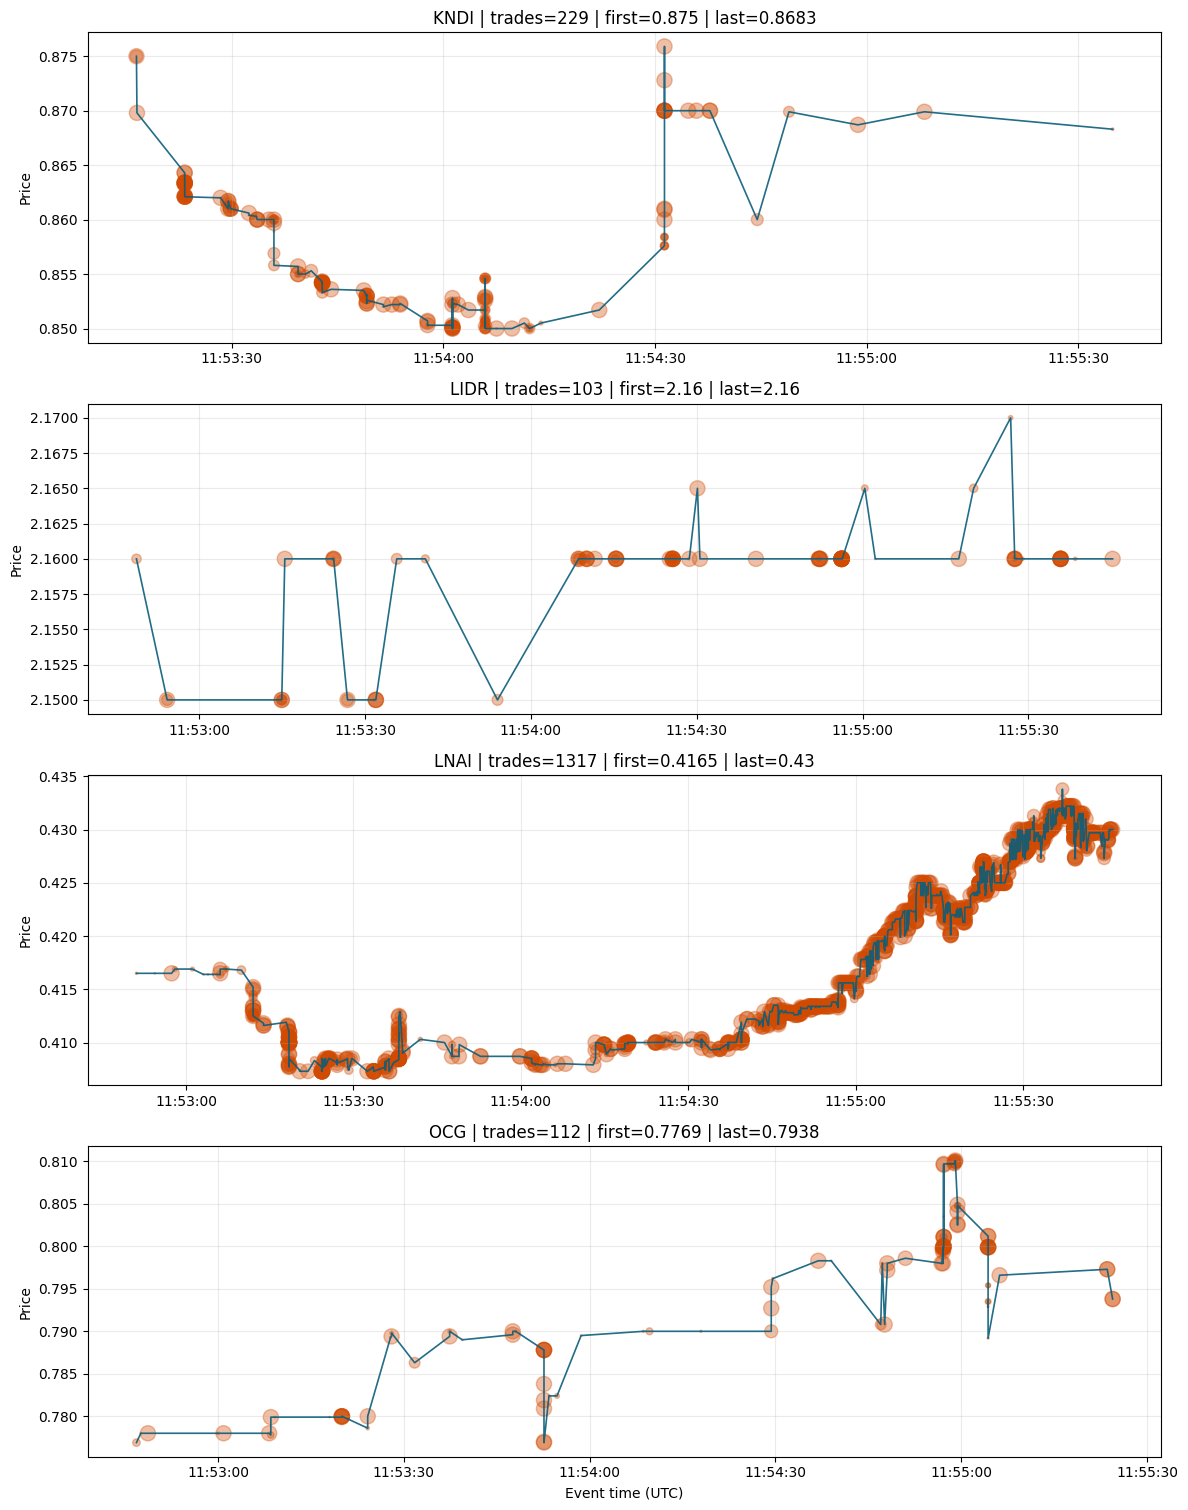

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

trades_path = PROJECT_ROOT / "data" / "curated_ws" / label / "normalized" / "trades.parquet"
if not trades_path.exists():
    raise FileNotFoundError(f"No existe trades.parquet: {trades_path}")

trades_df = pd.read_parquet(trades_path).copy()
if trades_df.empty:
    raise ValueError("El dataset de trades est? vac?o para este run")

trades_df["event_dt_utc"] = pd.to_datetime(trades_df["event_time"], unit="ms", utc=True, errors="coerce")
trades_df = trades_df.sort_values(["sym", "event_dt_utc", "sequence"]).reset_index(drop=True)

summary = trades_df.groupby("sym").agg(
    trades=("sym", "size"),
    first_price=("price", "first"),
    last_price=("price", "last"),
    min_price=("price", "min"),
    max_price=("price", "max")
).reset_index()
summary["price_change"] = summary["last_price"] - summary["first_price"]
display(summary)

symbols = summary["sym"].tolist()
fig, axes = plt.subplots(len(symbols), 1, figsize=(12, max(4, 3.8 * len(symbols))), sharex=False)
if len(symbols) == 1:
    axes = [axes]

for ax, sym in zip(axes, symbols):
    data = trades_df[trades_df["sym"] == sym].copy()
    first_price = data["price"].iloc[0]
    last_price = data["price"].iloc[-1]
    ax.plot(data["event_dt_utc"], data["price"], linewidth=1.2, alpha=0.9, color="#0b5d7a")
    ax.scatter(data["event_dt_utc"], data["price"], s=data["size"].clip(upper=100) * 1.2, alpha=0.35, color="#d04a02")
    ax.set_title(f"{sym} | trades={len(data)} | first={first_price} | last={last_price}")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Event time (UTC)")
plt.tight_layout()
plt.show()


## Celda 9. Captura robusta con reconexi?n y resuscripci?n

Esta celda lanza una variante m?s robusta del capturador, pensada como primer paso real de la fase 2 operativa. Si la conexi?n se corta durante la ventana de captura, el proceso intenta reconectar, reautenticar y resuscribirse autom?ticamente.

Motivo: la fase 1 valida el transporte b?sico, pero una ingesta real necesita tolerar cortes breves de red o del socket sin obligarte a relanzar manualmente el proceso.

Resultado esperado: un `events_resilient.jsonl`, un `capture_resilient_meta.json` y un `capture_resilient_log.jsonl` con trazabilidad t?cnica de reconexiones y reanudaci?n de la sesi?n.

In [11]:
import subprocess, sys

script = CELL_CODE_DIR / "14_capture_stream_resilient.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--feed-mode", "realtime",
    "--channels", "AM,T",
    "--symbols", "LIDR,OCG",
    "--duration-sec", "30",
    "--label", f"{label}_resilient",
    "--max-reconnects", "5",
    "--reconnect-delay-sec", "2"
], capture_output=True, text=True, check=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)


{
  "started_at_utc": "2026-03-17T11:55:58.018964+00:00",
  "finished_at_utc": "2026-03-17T11:56:28.407340+00:00",
  "feed_mode": "realtime",
  "ws_url": "wss://socket.massive.com/stocks",
  "api_key_env": "POLYGON_API_KEY",
  "channels": [
    "AM",
    "T"
  ],
  "symbols": [
    "LIDR",
    "OCG"
  ],
  "subscription": "AM.LIDR,AM.OCG,T.LIDR,T.OCG",
  "duration_sec": 30,
  "total_messages": 28,
  "total_events": 62,
  "event_counts": {
    "status": 5,
    "AM": 2,
    "T": 55
  },
  "successful_connections": 1,
  "reconnect_attempts": 0,
  "raw_path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\raw_ws\\prototype_run_phase3_A_resilient\\events_resilient.jsonl",
  "log_path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\raw_ws\\prototype_run_phase3_A_resilient\\capture_resilient_log.jsonl",
  "curated_dir": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A_resilient"
}

Raw events: C:\TSIS_Data\v1\WebSocket_SmallCaps\data\raw_ws\prototype_run_phas

## Celda 10. Revisi?n del log t?cnico de captura robusta

Esta celda inspecciona el log t?cnico generado por la captura robusta. Est? pensada para verificar visualmente si hubo reconexiones, cu?ntas conexiones efectivas se abrieron y qu? secuencia de eventos operativos sigui? el capturador.

Motivo: si vamos a fiarnos de una ingesta con reintentos, hace falta ver claramente qu? hizo el proceso y no solo si termin? con c?digo 0.

Resultado esperado: una tabla corta con eventos de control (`connect_attempt`, `connected`, `auth_reply`, `subscribed`, `connection_error`, etc.) y un resumen t?cnico de la sesi?n.

In [12]:
import json
import pandas as pd
from IPython.display import display

run_dir = PROJECT_ROOT / "data" / "raw_ws" / f"{label}_resilient"
meta_path = run_dir / "capture_resilient_meta.json"
log_path = run_dir / "capture_resilient_log.jsonl"

meta = json.loads(meta_path.read_text(encoding="utf-8"))
print(json.dumps(meta, indent=2, ensure_ascii=False))

rows = []
with log_path.open("r", encoding="utf-8") as handle:
    for line in handle:
        rows.append(json.loads(line))

log_df = pd.DataFrame(rows)
display(log_df.head(30))


{
  "started_at_utc": "2026-03-17T11:55:58.018964+00:00",
  "finished_at_utc": "2026-03-17T11:56:28.407340+00:00",
  "feed_mode": "realtime",
  "ws_url": "wss://socket.massive.com/stocks",
  "api_key_env": "POLYGON_API_KEY",
  "channels": [
    "AM",
    "T"
  ],
  "symbols": [
    "LIDR",
    "OCG"
  ],
  "subscription": "AM.LIDR,AM.OCG,T.LIDR,T.OCG",
  "duration_sec": 30,
  "total_messages": 28,
  "total_events": 62,
  "event_counts": {
    "status": 5,
    "AM": 2,
    "T": 55
  },
  "successful_connections": 1,
  "reconnect_attempts": 0,
  "raw_path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\raw_ws\\prototype_run_phase3_A_resilient\\events_resilient.jsonl",
  "log_path": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\raw_ws\\prototype_run_phase3_A_resilient\\capture_resilient_log.jsonl",
  "curated_dir": "C:\\TSIS_Data\\v1\\WebSocket_SmallCaps\\data\\curated_ws\\prototype_run_phase3_A_resilient"
}


,ts_utc,type,ws_url,connection_num,payload,subscription
0,2026-03-17T11:55:58.019187+00:00,connect_attempt,wss://socket.massive.com/stocks,NaN,NaN,NaN
1,2026-03-17T11:55:58.493507+00:00,connected,NaN,1.0,NaN,NaN
2,2026-03-17T11:55:58.493934+00:00,auth_reply,NaN,NaN,"[{""ev"":""status"",""status"":""connected"",""message""...",NaN
3,2026-03-17T11:55:58.494176+00:00,subscribed,NaN,NaN,NaN,"AM.LIDR,AM.OCG,T.LIDR,T.OCG"
